In [41]:
import pandas as pd
from modules import Agent,Model
from DCAStrategy import DCAAgent
from LSStrategy import LSSAgent
import numpy as np
import torch
import pickle
device = "cuda" if torch.cuda.is_available() else "cpu"
import matplotlib.pyplot as plt
import seaborn as sns
import os
from preprocessing import Feature_Extractor, data_preprocessing


Start Trading

In [42]:
symbol = "BTC"
from_date ="2024-03-01"
to_date = "2024-10-15"
# from_date ="2023-05-18"
# to_date = "2024-06-18"
# from_date ="2023-01-15"
# to_date = "2023-12-01"
skip =1

In [43]:
df = pd.read_csv(f'DataTrading/{symbol}.csv')

In [44]:
df.tail

<bound method NDFrame.tail of             Date     Close      Open      High       Low
0     2018-01-01   13444.9   13850.5   13921.5   12877.7
1     2018-01-02   14754.1   13444.9   15306.1   12934.2
2     2018-01-03   15156.6   14754.1   15435.0   14579.7
3     2018-01-04   15180.1   15156.5   15408.7   14244.7
4     2018-01-05   16954.8   15180.1   17126.9   14832.4
...          ...       ...       ...       ...       ...
2579  2025-01-23  103912.1  103681.3  106806.5  101281.6
2580  2025-01-24  104862.3  103913.6  107102.2  102760.0
2581  2025-01-25  104742.9  104861.4  105255.6  104133.9
2582  2025-01-26  102637.8  104743.8  105399.8  102543.8
2583  2025-01-27   99121.5  102618.3  103234.8   98834.3

[2584 rows x 5 columns]>

Trade without LSTM

With LSTM

[0. 1. 0.]
[1. 0. 0.]
[0. 0. 1.]
[1. 0. 0.]
[0. 0. 1.]
[0. 0. 1.]
[0. 0. 1.]
[0. 0. 1.]
[1. 0. 0.]
[0. 0. 1.]
[1. 0. 0.]
[0. 0. 1.]
[0. 0. 1.]
[1. 0. 0.]
[0. 0. 1.]
[0. 1. 0.]
[0. 1. 0.]
[0. 1. 0.]
[0. 1. 0.]
[0. 1. 0.]
[0. 0. 1.]
[0. 1. 0.]
[0. 1. 0.]
[1. 0. 0.]
[1. 0. 0.]
[1. 0. 0.]
[1. 0. 0.]
[1. 0. 0.]
[1. 0. 0.]
[0. 0. 1.]
[1. 0. 0.]
[0. 0. 1.]
[0. 1. 0.]
[0. 0. 1.]
[1. 0. 0.]
[0. 1. 0.]
[0. 0. 1.]
[0. 0. 1.]
[1. 0. 0.]
[0. 1. 0.]
[1. 0. 0.]
[0. 0. 1.]
[0. 1. 0.]
[0. 1. 0.]
[0. 0. 1.]
[0. 1. 0.]
[0. 1. 0.]
[0. 1. 0.]
[0. 0. 1.]
[1. 0. 0.]
[1. 0. 0.]
[1. 0. 0.]
[1. 0. 0.]
[1. 0. 0.]
[0. 0. 1.]
[1. 0. 0.]
[0. 1. 0.]
[0. 1. 0.]
[0. 1. 0.]
[0. 0. 1.]
[0. 1. 0.]
[0. 1. 0.]
[0. 1. 0.]
[1. 0. 0.]
[1. 0. 0.]
[1. 0. 0.]
[1. 0. 0.]
[1. 0. 0.]
[0. 0. 1.]
[1. 0. 0.]
[0. 0. 1.]
[0. 1. 0.]
[0. 0. 1.]
[1. 0. 0.]
[0. 1. 0.]
[1. 0. 0.]
[0. 1. 0.]
[1. 0. 0.]
[1. 0. 0.]
[0. 1. 0.]
[1. 0. 0.]
[1. 0. 0.]
[0. 0. 1.]
[0. 0. 1.]
[0. 0. 1.]
[0. 0. 1.]
[0. 1. 0.]
[0. 0. 1.]
[0. 1. 0.]
[0. 1. 0.]
[0. 1. 0.]

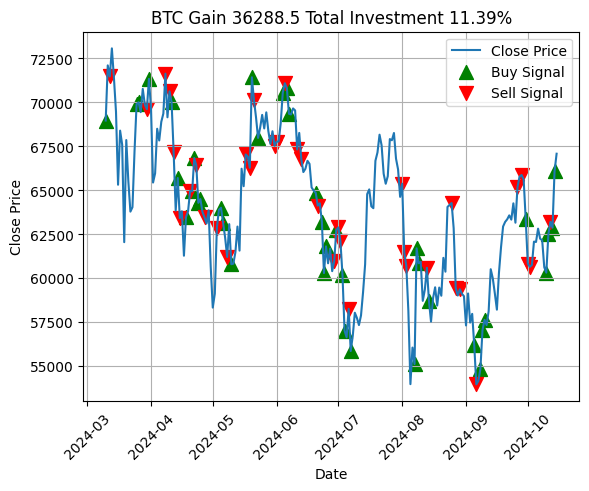

In [45]:
df['Date'] = pd.to_datetime(df['Date'])
df_init = df[['Close']]  
df_init = data_preprocessing(df_init, Feature_Extractor)
real_trend = df_init['Close'].tolist()
parameters = [df_init[cl].tolist() for cl in df_init.columns]
initial_money = np.max(parameters[0]) * 3
# initial_money =  100000
minmax = pickle.load(open(f"checkpoint/{symbol}_DCAscaler.pkl", 'rb'))
scaled_parameters = minmax.transform(np.array(parameters).T).T.tolist()
with open(f"checkpoint/{symbol}_DCAmodel.pkl", 'rb') as fopen:
    model = pickle.load(fopen)
df = df[['Date', 'Close']]
#Preprocess Dataframe
df = data_preprocessing(df, Feature_Extractor)
selected_data = df.loc[(df['Date'] >= from_date) & (df['Date'] <= to_date),:]
data_list = selected_data.values.tolist()

agent3 = Agent(model = model,
                timeseries = scaled_parameters,
                skip = skip,
                initial_money = initial_money,
                real_trend = real_trend,
                minmax = minmax,
                window_size = 10)

trade_results = []
for row in data_list:
    #ensure first column is Date
    date = row[0]
    value = row[1:]
    result = agent3.trade(value, date = date)
    trade_results.append(result)


result = pd.DataFrame(trade_results)

# Convert the 'date' column to datetime format
result['date'] = pd.to_datetime(result['date'])
result = result[result['status'] != 'data not enough to trade']
df_action_2 = result[result['action'] == 2]

# Sắp xếp DataFrame theo timestamp hoặc date để đảm bảo lấy hàng cuối cùng
df_action_2_sorted = df_action_2.sort_values(by='date')

# Lấy giá trị total_investment của hàng cuối cùng
last_total_investment = df_action_2_sorted.iloc[-1]['total_investment']
df_sorted = result.sort_values(by='date')

# Lấy giá trị total của hàng cuối cùng
last_total = df_sorted.iloc[-1]['total']
investmentvalue = (last_total-initial_money)/initial_money *100
total_gain = result['gain'].sum()
investGain = total_gain/initial_money *100

print(last_total_investment)
print(investmentvalue)
print(total_gain)
print(investGain)

# Mark buy and sell actions
buy_signals = result[result['action'] == 1]
sell_signals = result[result['action'] == 2]
plt.plot(result['date'], result['close'], linestyle='-', label='Close Price')

plt.scatter(buy_signals['date'], buy_signals['close'], marker='^', color='g', s=100, label='Buy Signal')
plt.scatter(sell_signals['date'], sell_signals['close'], marker='v', color='r', s=100, label='Sell Signal')

# Customize the plot
plt.title(f'{symbol} Gain {round(total_gain,2)} Total Investment {round(investGain,2)}%')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Show the plot
plt.show()

In [46]:
# Add mapping for action labels
action_map = {1: 'Buy', 2: 'Sell', 0: 'Hold'}

# Print date, action, and price
for _, row in result.iterrows():
    action_label = action_map.get(row['action'], 'No Action')
    price = row['close']  # Assuming 'close' contains the price at that date
    print(f"Date: {row['date']}, Action: {action_label}, Price: {price}")


Date: 2024-03-10 00:00:00, Action: Buy, Price: 68964.8
Date: 2024-03-11 00:00:00, Action: Hold, Price: 72099.1
Date: 2024-03-12 00:00:00, Action: Sell, Price: 71470.2
Date: 2024-03-13 00:00:00, Action: Hold, Price: 73066.3
Date: 2024-03-14 00:00:00, Action: Hold, Price: 71387.5
Date: 2024-03-15 00:00:00, Action: Hold, Price: 69463.7
Date: 2024-03-16 00:00:00, Action: Hold, Price: 65314.2
Date: 2024-03-17 00:00:00, Action: Hold, Price: 68391.2
Date: 2024-03-18 00:00:00, Action: Hold, Price: 67594.1
Date: 2024-03-19 00:00:00, Action: Hold, Price: 62050.0
Date: 2024-03-20 00:00:00, Action: Hold, Price: 67854.0
Date: 2024-03-21 00:00:00, Action: Hold, Price: 65503.8
Date: 2024-03-22 00:00:00, Action: Hold, Price: 63785.5
Date: 2024-03-23 00:00:00, Action: Hold, Price: 64037.8
Date: 2024-03-24 00:00:00, Action: Hold, Price: 67211.9
Date: 2024-03-25 00:00:00, Action: Buy, Price: 69892.0
Date: 2024-03-26 00:00:00, Action: Buy, Price: 69999.3
Date: 2024-03-27 00:00:00, Action: Hold, Price: 694

In [47]:
action_map = {1: 'Buy', 2: 'Sell', 0: 'Hold'}

# Initialize variables to track total buy price and total gain
total_buy_price = 0
total_gain = 0

# Print date, action, price, and calculate cumulative investment return
for _, row in result.iterrows():
    action_label = action_map.get(row['action'], 'No Action')
    price = row['close']

    if row['action'] == 1:
        total_buy_price += price

print(result['gain'].sum()/total_buy_price*100)
print(total_buy_price)

1.4280102186638073
2541193.3000000003


In [48]:
result.tail(10)

,status,action,close,balance,timestamp,date,total,investment,total_investment,all_bought,all_sold,gain
219,do nothing,0,62819.4,351871.2,2025-01-31 10:22:33.229072,2024-10-06,351871.2,NaN,NaN,NaN,NaN,NaN
220,do nothing,0,62245.6,351871.2,2025-01-31 10:22:33.230222,2024-10-07,351871.2,NaN,NaN,NaN,NaN,NaN
221,do nothing,0,62157.0,351871.2,2025-01-31 10:22:33.231901,2024-10-08,351871.2,NaN,NaN,NaN,NaN,NaN
222,do nothing,0,60628.8,351871.2,2025-01-31 10:22:33.232988,2024-10-09,351871.2,NaN,NaN,NaN,NaN,NaN
223,"buy 1 unit, cost 60316.200000",1,60316.2,291555.0,2025-01-31 10:22:33.233970,2024-10-10,351871.2,NaN,NaN,NaN,NaN,NaN
224,"buy 1 unit, cost 62499.400000",1,62499.4,229055.6,2025-01-31 10:22:33.234947,2024-10-11,354054.4,NaN,NaN,NaN,NaN,NaN
225,"sell 1 unit, price 63205.100000",2,63205.1,292260.7,2025-01-31 10:22:33.236941,2024-10-12,355465.8,4.789592,1.544362,2349741.3,2386029.8,2888.9
226,"buy 1 unit, cost 62870.900000",1,62870.9,229389.8,2025-01-31 10:22:33.237943,2024-10-13,355131.6,NaN,NaN,NaN,NaN,NaN
227,"buy 1 unit, cost 66081.700000",1,66081.7,163308.1,2025-01-31 10:22:33.239501,2024-10-14,361553.2,NaN,NaN,NaN,NaN,NaN
228,do nothing,0,67077.5,163308.1,2025-01-31 10:22:33.240079,2024-10-15,364540.6,NaN,NaN,NaN,NaN,NaN


In [49]:
(121778.8-initial_money)/initial_money * 100

-61.76148830853363

In [50]:
151275.5-initial_money

-167196.09999999998